In [1]:
from src.measure_ir import *
import matplotlib.pyplot as plt
import numpy as np
from src.audio_device import AudioDevice
import soundfile as sf

peak: 239999 expected: 239999


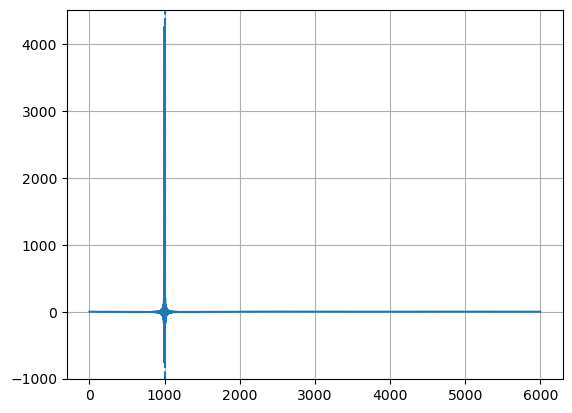

In [2]:
sweep = make_sweep()
ir_test = estimate_ir(sweep, sweep)

peak = np.argmax(np.abs(ir_test))
print("peak:", peak, "expected:", len(sweep) - 1)

plt.figure()
plt.plot(ir_test[peak-1000:peak+5000])
plt.axvline(1000, linestyle="--")
plt.grid(True)
plt.show()

In [3]:
arthur, fs = sf.read('data/arthur_clip_48k.wav')
ad = AudioDevice(fs=fs)

arthur.shape

(238834,)

In [4]:
error_mic, ref_mic = ad.play(panel_out=arthur)

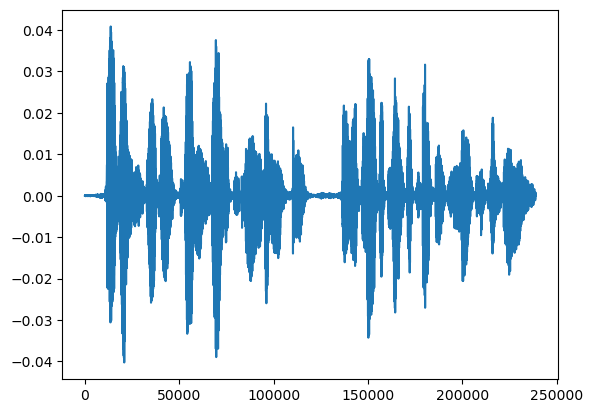

In [5]:
plt.plot(error_mic)
plt.show()

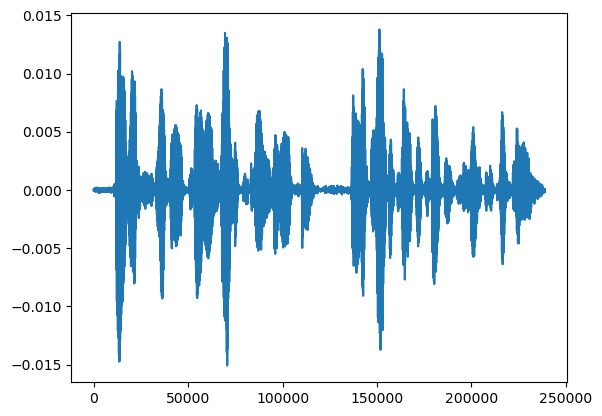

In [6]:
plt.plot(ref_mic)
plt.show()

In [7]:
import sounddevice as sd

print(sd.query_hostapis())
print(sd.query_devices())
print(sd.default.device)

({'name': 'MME', 'devices': [0, 1, 2, 3, 4, 5], 'default_input_device': 1, 'default_output_device': 4}, {'name': 'Windows DirectSound', 'devices': [6, 7, 8, 9, 10, 11], 'default_input_device': 6, 'default_output_device': 9}, {'name': 'ASIO', 'devices': [12], 'default_input_device': 12, 'default_output_device': 12}, {'name': 'Windows WASAPI', 'devices': [13, 14, 15, 16], 'default_input_device': 16, 'default_output_device': 13}, {'name': 'Windows WDM-KS', 'devices': [17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28], 'default_input_device': 17, 'default_output_device': 21})
   0 Microsoft Sound Mapper - Input, MME (2 in, 0 out)
   1 Microphone Array (Intel® Smart , MME (4 in, 0 out)
   2 Analogue 1 + 2 (Focusrite USB A, MME (8 in, 0 out)
   3 Microsoft Sound Mapper - Output, MME (0 in, 2 out)
   4 Speakers (Focusrite USB Audio), MME (0 in, 8 out)
   5 Speakers (Realtek(R) Audio), MME (0 in, 2 out)
   6 Primary Sound Capture Driver, Windows DirectSound (2 in, 0 out)
   7 Microphone Array (I

In [9]:
error_ir, _, loopback_ir = measure_ir(f0=160)

Estimated hardware latency: 244317 samples
Estimated distance to error mic: 16.44 cm
Estimated distance to reference mic: 82.89 cm


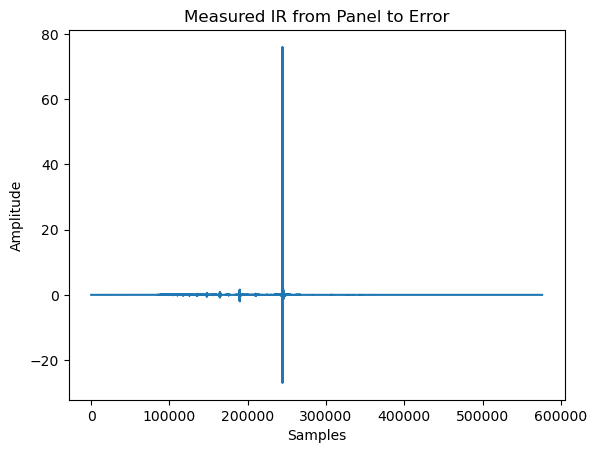

In [10]:
plt.plot(error_ir)
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.title('Measured IR from Panel to Error')
plt.show()

peak: 244340


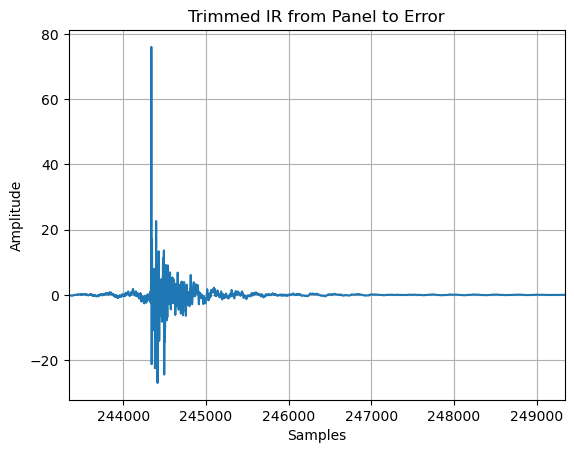

In [16]:
peak = np.argmax(np.abs(error_ir))
print("peak:", peak)

plt.figure()
plt.plot(range(peak - 1000, peak + 5000, 1), (error_ir[peak-1000:peak+5000]))
plt.xlim(peak - 1000, peak + 5000)

plt.axvline(1000, linestyle="--")
plt.grid(True)
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.title('Trimmed IR from Panel to Error')
plt.show()

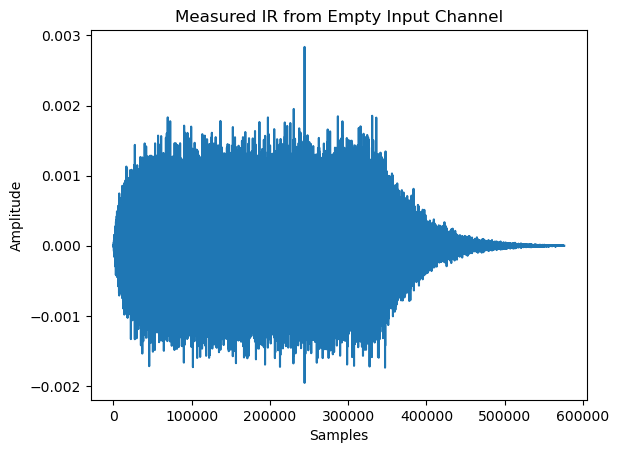

In [17]:
plt.plot(loopback_ir)
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.title('Measured IR from Empty Input Channel')
plt.show()

In [19]:
player_channel = 0
duration = 5.0
f0 = 160
f1 = 20000

sweep = make_sweep(fs, duration, f0, f1)

silence = np.zeros(int(fs * 2.0), dtype=np.float32)  # 2 sec decay
play_signal = np.concatenate([sweep, silence])

out = np.zeros((len(play_signal), 2), dtype=np.float32)
out[:len(sweep), player_channel] = sweep

# Play sweep, record 3 channels: [error_mic, reference_mic, loopback (no wires)]
rec = sd.playrec(
    out,
    samplerate=fs,
    channels=8,
    dtype='float32',
    blocking=True
)

for ch in range(rec.shape[1]):
    rms = np.sqrt(np.mean(rec[:, ch] ** 2))
    peak = np.max(np.abs(rec[:, ch]))
    print(ch, "rms", rms, "peak", peak)

for ch in range(rec.shape[1]):
    ir = estimate_ir(rec[:, ch], sweep, fs, f0, f1)
    peak_idx = np.argmax(np.abs(ir))
    peak_val = np.max(np.abs(ir))
    print(ch, "ir peak idx", peak_idx, "ir peak val", peak_val)

0 rms 0.013238604 peak 0.08045101
1 rms 0.0044314153 peak 0.027993798
2 rms 1.0875829e-05 peak 4.4584274e-05
3 rms 1.2247966e-05 peak 5.1140785e-05
4 rms 8.1195185e-06 peak 1.9550323e-05
5 rms 8.047638e-06 peak 2.026558e-05
6 rms 8.516903e-06 peak 3.015995e-05
7 rms 7.932292e-06 peak 1.9431114e-05
0 ir peak idx 244340 ir peak val 78.43074
1 ir peak idx 244433 ir peak val 12.8737545
2 ir peak idx 244317 ir peak val 0.0032185798
3 ir peak idx 244316 ir peak val 0.03451643
4 ir peak idx 244316 ir peak val 0.0012530521
5 ir peak idx 117955 ir peak val 0.00069916766
6 ir peak idx 244316 ir peak val 0.08167362
7 ir peak idx 244316 ir peak val 0.0010901642
